# Final Project: Literacy Rates Analysis

Name: Amelia Pucek

Date: 05/16/2026

Course: CS-215


## Global Literacy Rates Analysis (Our World in Data)

### Project Overview
In this project, I will analyze global literacy rates using data from Our World in Data. The goal is to explore how literacy rates vary across countries, over time, and by region.

### Research Questions
- How have global literacy rates changed over time?
- Which countries have the highest and lowest literacy rates?
- How do literacy rates differ by region or income level?
- Are there any long-term trends or patterns in literacy improvement?

### Data Sources
- Our World in Data: https://ourworldindata.org/literacy
- Link to CSV file: https://drive.google.com/file/d/1eJLWJfvaSFvdtjYre9ZhpApTzM9pjhRN/view?usp=drive_link

## Question 1: How have global literacy rates changed over time?
For the first section, I will answer the first question by creating a table and graph to see how literacy rates around the globe have changed from 1970 to 2023.

In [2]:
# Import libraries needed for analysis

import pandas as pd              # for data manipulation
import numpy as np               # for numerical operations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns            # for nicer visualizations

# Make plots look a bit nicer
sns.set(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Question 1: How have global literacy rates changed over time?

# Load literacy dataset from Our World in Data

df = pd.read_csv("global_literacy_rates.csv")

# Show first few rows
df.head()

,Entity,Code,Year,Literacy rate among adults
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [5]:
# Understand the dataset structure

print("Shape:", df.shape)   # rows and columns
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())

df.describe()

Shape: (1725, 4)

Columns:
 Index(['Entity', 'Code', 'Year', 'Literacy rate among adults'], dtype='object')

Missing values:
 Entity                          0
Code                          729
Year                            0
Literacy rate among adults      0
dtype: int64


,Year,Literacy rate among adults
count,1725.000000,1725.000000
mean,2003.860870,77.336331
std,13.176796,19.335627
min,1970.000000,9.000000
25%,1994.000000,64.492390
50%,2007.000000,82.157580
75%,2015.000000,94.000000
max,2023.000000,100.000000


In [6]:
# Rename columns to make them easier to work with
df = df.rename(columns={
    "Entity": "Country",
    "Code": "Country Code",
    "Year": "Year",
    "Literacy rate among adults": "Literacy Rate Among Adults"
})

# Check the updated column names
print(df.columns)

# Display first few cleaned rows
df.head()

Index(['Country', 'Country Code', 'Year', 'Literacy Rate Among Adults'], dtype='object')


,Country,Country Code,Year,Literacy Rate Among Adults
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


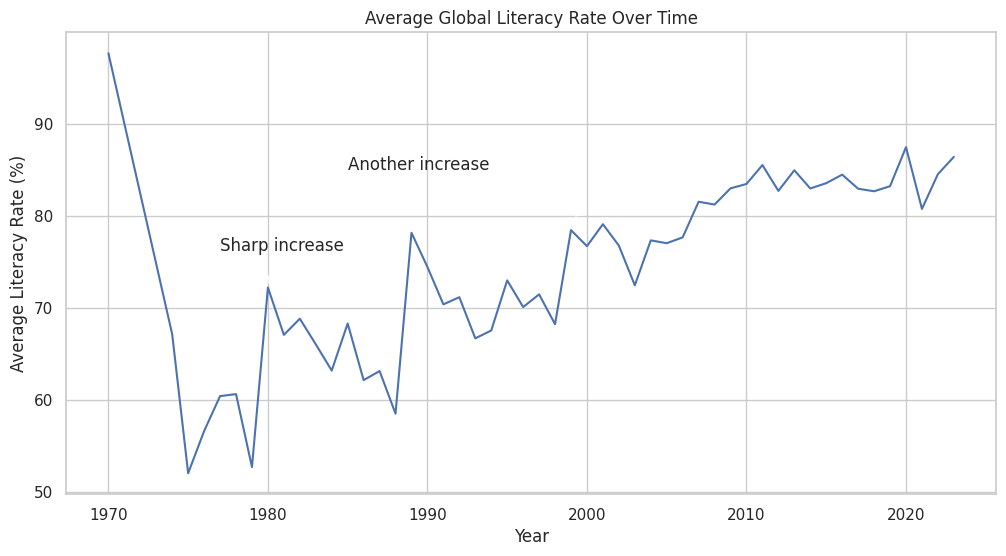

In [9]:
# Group data by year and calculate average literacy rate
yearly_literacy = df.groupby("Year")["Literacy Rate Among Adults"].mean()

# Create the plot
plt.figure(figsize=(12,6))

plt.plot(yearly_literacy.index,
         yearly_literacy.values)

# Add labels and title
plt.title("Average Global Literacy Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Literacy Rate (%)")

# Annotate key year (spike in 1980)
plt.annotate(
    "Sharp increase",
    xy=(1980, yearly_literacy.loc[1980]),
    xytext=(1977, yearly_literacy.loc[1980] + 4),
    arrowprops=dict(arrowstyle="->")
)

# Annotate key year (spike around 1988)
plt.annotate(
    "Another increase",
    xy=(2000, 80),
    xytext=(1985, 85),
    arrowprops=dict(arrowstyle="->")
)

# Show the graph
plt.show()

### Interpretation of Visualization

This graph shows the average literacy rate across all countries (with data available) over time.

Overall, literacy rates show a general upward trend from 1970 to 2023, suggesting that global access to education has improved over the past several decades.

There are fluctuations in the earlier years, with visible increases and decreases in the global average. These changes are likely influenced by differences in data availability across years and the varying number of countries included in each time period.

Because of this, early-year averages may not be fully comparable to later years, where data coverage is more complete and stable.

## New Technique: Linear Regression Trend Analysis

In this section, I applied a linear regression model to analyze the overall trend in global literacy rates over time. Instead of only visualizing the data as a line plot, regression allows us to mathematically estimate the direction and strength of the trend.

Specifically, I used a simple linear regression between Year (independent variable) and Average Global Literacy Rate (dependent variable). This produces a best-fit line that summarizes the overall long-term trend in the data.

From this model, I extracted:

- The slope, which represents the average yearly change in literacy rate
- The intercept, which is the baseline value of the model
- The R-squared value, which measures how well the line fits the data

This technique helps move beyond visualization into statistical interpretation of trends.



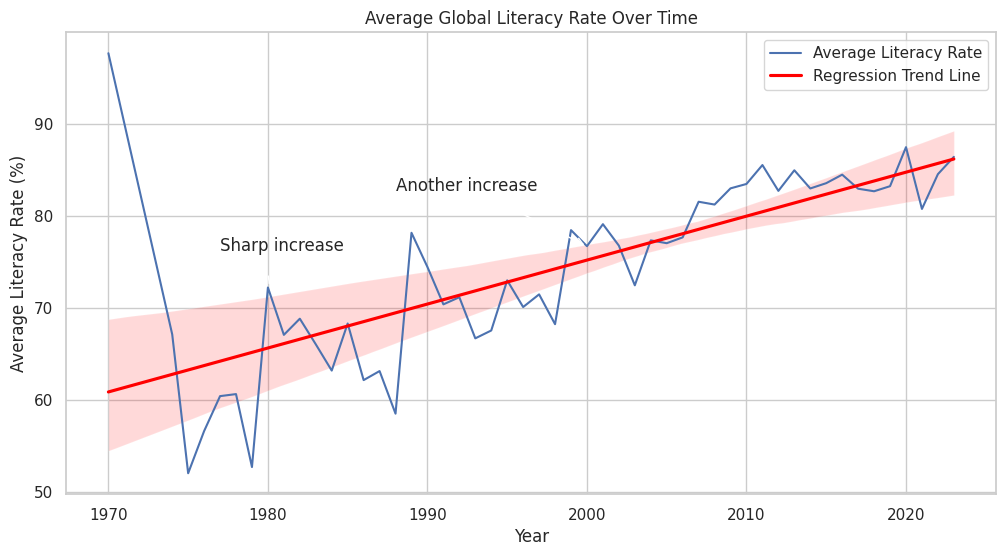

In [8]:
# Group data by year and calculate average literacy rate
yearly_literacy = df.groupby("Year")["Literacy Rate Among Adults"].mean()

# Create the plot
plt.figure(figsize=(12,6))

# Original literacy rate line
plt.plot(
    yearly_literacy.index,
    yearly_literacy.values,
    label="Average Literacy Rate"
)

# NEW TECHNIQUE:
# Add regression trend line to show overall direction
sns.regplot(
    x=yearly_literacy.index,
    y=yearly_literacy.values,
    scatter=False,   # removes scatter dots
    color="red",
    label="Regression Trend Line"
)

# Add labels and title
plt.title("Average Global Literacy Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Average Literacy Rate (%)")

# Annotate key year (spike in 1980)
plt.annotate(
    "Sharp increase",
    xy=(1980, yearly_literacy.loc[1980]),
    xytext=(1977, yearly_literacy.loc[1980] + 4),
    arrowprops=dict(arrowstyle="->")
)

# Annotate another spike
plt.annotate(
    "Another increase",
    xy=(2000, yearly_literacy.loc[2000]),
    xytext=(1988, yearly_literacy.loc[2000] + 6),
    arrowprops=dict(arrowstyle="->")
)

# Show legend
plt.legend()

# Show the graph
plt.show()

In [11]:
from scipy.stats import linregress

# Perform linear regression on literacy over time
regression = linregress(
    yearly_literacy.index,
    yearly_literacy.values
)

# Print regression statistics
print("Slope:", regression.slope)
print("Intercept:", regression.intercept)
print("R-squared:", regression.rvalue**2)

Slope: 0.4772388851715224
Intercept: -879.2710327148842
R-squared: 0.521262830633658


### Interpretation of Regression Results

The regression output shows:

- Slope ≈ 0.48

- Intercept ≈ -879.27

- R² ≈ 0.52

The positive slope (0.48) indicates that global literacy rates have generally increased over time. On average, the model suggests literacy rates increase by about 0.48 percentage points per year, showing steady long-term improvement.

The R² value of 0.52 means that about 52% of the variation in literacy rates can be explained by time alone. This indicates a moderate relationship. While there is a clear upward trend, other factors (such as regional differences, missing data, and uneven country coverage) also strongly influence the results.

Overall, the regression confirms the pattern seen in the visualization. It shows that global literacy has improved over time, but not in a perfectly smooth or uniform way.

## Question 2: Which countries have the highest and lowest literacy rates?

In this section, I will answer the second question by analyzing which countries currently have the highest and lowest adult literacy rates in the dataset. To do this, I'll use the most recent literacy rate available for each country.

In [15]:
# Question 2: Which countries have the highest and lowest literacy rates?

# Sort data by year so the newest records appear last
sorted_df = df.sort_values("Year")

# Keep only the most recent literacy entry for each country
latest_data = sorted_df.groupby("Country").tail(1)

# Find the 10 countries with the highest literacy rates
highest_literacy = latest_data.sort_values(
    "Literacy Rate Among Adults",
    ascending=False
).head(10)

# Find the 10 countries with the lowest literacy rates
lowest_literacy = latest_data.sort_values(
    "Literacy Rate Among Adults",
    ascending=True
).head(10)

# Display results
print("Top 10 Countries with Highest Literacy Rates")
display(highest_literacy[[
    "Country",
    "Year",
    "Literacy Rate Among Adults"
]])

print("\nTop 10 Countries with Lowest Literacy Rates")
display(lowest_literacy[[
    "Country",
    "Year",
    "Literacy Rate Among Adults"
]])

Top 10 Countries with Highest Literacy Rates


,Country,Year,Literacy Rate Among Adults
720,Lithuania,2011,100.0
708,Latvia,2011,100.0
1311,Slovenia,1991,100.0
581,Kazakhstan,2009,100.0
1052,North Korea,2008,100.0
422,Estonia,2011,100.0
43,Azerbaijan,2023,100.0
1395,Spain,2021,100.0
1261,San Marino,2022,100.0
1245,Russia,2021,100.0



Top 10 Countries with Lowest Literacy Rates


,Country,Year,Literacy Rate Among Adults
1377,South Sudan,2008,27.00000
210,Chad,2019,30.62792
716,Liberia,1984,32.00000
845,Mali,2018,35.00000
1034,Niger,2022,35.60971
1716,Yemen,1994,37.00000
3,Afghanistan,2021,37.00000
507,Guinea,2018,40.00000
129,Burkina Faso,2022,40.92361
156,Central African Republic,2019,42.44279


### Table Reflection

As you can see, the table displays the top 10 countries with the highest and lowest literacy rates, but the problem is that the years are different. To make a good and fair comparison, the years need to be the same. First, let's see how many countries appear for each year.

In [16]:
# Count how many countries appear in each year

year_counts = df["Year"].value_counts().sort_index()

# Display the counts
print(year_counts)

Year
1970     3
1974     3
1975    13
1976    20
1977    13
1978    14
1979    19
1980    32
1981    31
1982    24
1983    14
1984    19
1985    20
1986    18
1987    17
1988    19
1989    26
1990    32
1991    39
1992    24
1993    19
1994    24
1995    22
1996    26
1997    20
1998    23
1999    26
2000    60
2001    47
2002    36
2003    31
2004    37
2005    39
2006    46
2007    46
2008    48
2009    45
2010    57
2011    68
2012    56
2013    47
2014    53
2015    58
2016    59
2017    53
2018    60
2019    60
2020    44
2021    43
2022    44
2023    28
Name: count, dtype: int64


### Justification of Using Multiple Years

From the year distribution, we can see that there is no single year that contains data for all countries. Instead, different countries report literacy data in different years, and the number of observations varies significantly across time.

For example, earlier years such as the 1970s and 1980s contain very few country records, while more recent years like 2010-2019 contain much more complete data.

Because of this inconsistency, selecting a single year would significantly reduce the number of countries included in the analysis. To maintain a more comprehensive global comparison, we instead use the most recent available literacy rate for each country.

This approach allows us to include as many countries as possible while still focusing on relatively recent data, even though it introduces some variation in reporting years.

### Bar Chart for Top 10 Highest and Lowest Literacy Rates

To get a better visualization, I'll create two bar charts: One for the top 10 highest literacy rates, and one for the top 10 lowest literacy rates.

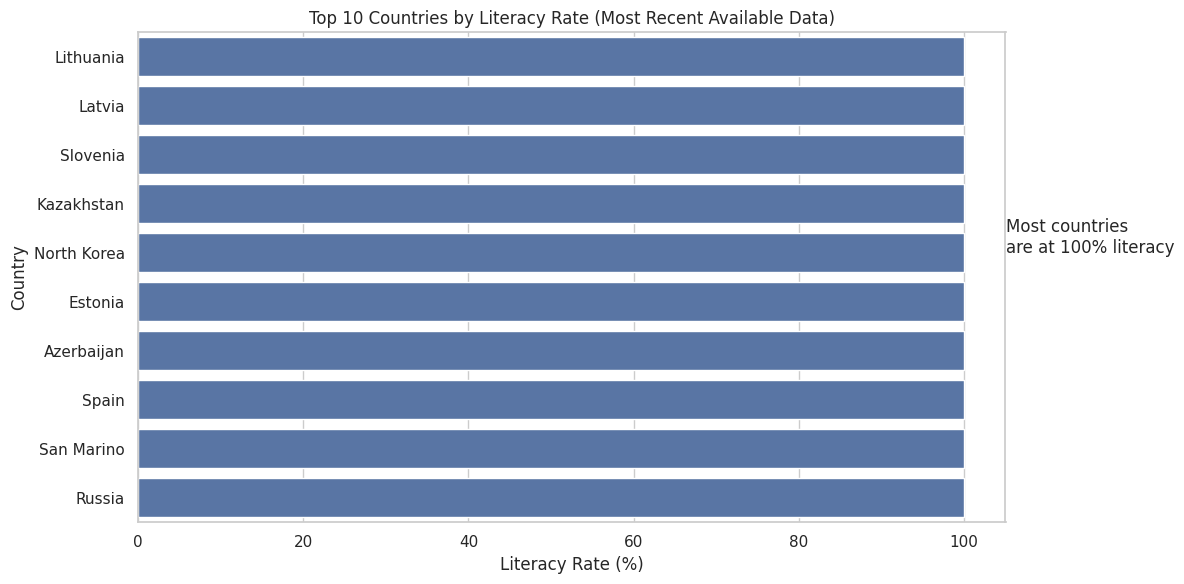

In [64]:
# Visualize Top 10 Countries with Highest Literacy Rate

# Create a new figure with a specific size
plt.figure(figsize=(12,6))

# Create a horizontal bar plot for highest literacy countries
sns.barplot(
    data=highest_literacy,  # dataset containing top 10 countries
    x="Literacy Rate Among Adults",  # values on x-axis
    y="Country"  # countries on y-axis
)

# Add title and axis labels for clarity
plt.title("Top 10 Countries by Literacy Rate (Most Recent Available Data)")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Country")

# Annotation
plt.annotate(
    "Most countries\nare at 100% literacy",
    xy=(100, 0),
    xytext=(105, 4),
)

# Improve layout so labels don't get cut off
plt.tight_layout()

# Display the plot
plt.show()

### Top 10 Highest Literacy Rate Reflection

These countries show extremely high literacy rates, many at or near 100%. This reflects strong education systems and widespread access to basic schooling. However, it is important to note that these values come from the most recent available data for each country, so the reporting years are not identical across all countries.

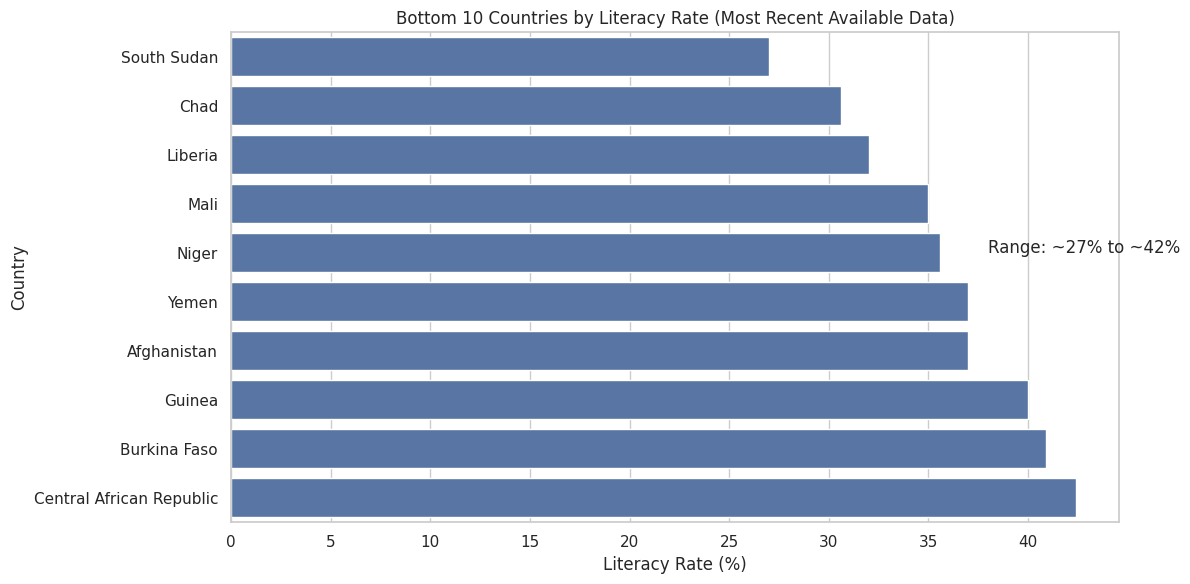

In [59]:
# Visualize Top 10 Countries with Lowest Literacy Rate

# Create a new figure with a specific size
plt.figure(figsize=(12,6))

# Create a horizontal bar plot for lowest literacy countries
sns.barplot(
    data=lowest_literacy,  # dataset containing bottom 10 countries
    x="Literacy Rate Among Adults",  # values on x-axis
    y="Country"  # countries on y-axis
)

# Add title and axis labels for clarity
plt.title("Bottom 10 Countries by Literacy Rate (Most Recent Available Data)")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Country")

# Annotation
plt.annotate(
    "Range: ~27% to ~42%",
    xy=(35, 0),
    xytext=(38, 4),
)

# Improve layout so labels don't get cut off
plt.tight_layout()

# Display the plot
plt.show()

### Top 10 Lowest Literacy Rate Reflection

These countries have significantly lower literacy rates, ranging from approximately 27% to just over 40%. This suggests ongoing challenges such as limited access to education, economic barriers, and historical development constraints.

Together, these results highlight large global inequalities in access to education and literacy outcomes.

## Question 3: How do literacy rates differ by region or income level?

In this section, I will answer the third question by analyzing how literacy rates vary across different regions of the world. To do this, I will group countries into broader geographic regions and compare their average literacy rates to identify patterns and differences.

In [21]:
# Question 3: How do literacy rates differ by region or income level?

# Create a simple mapping from country to region

# NOTE: This is a simplified grouping for analysis purposes
region_mapping = {
    "Afghanistan": "Asia",
    "Albania": "Europe",
    "Algeria": "Africa",
    "Argentina": "Americas",
    "Australia": "Oceania",
    "Austria": "Europe",
    "Azerbaijan": "Asia",
    "Bangladesh": "Asia",
    "Brazil": "Americas",
    "Canada": "Americas",
    "China": "Asia",
    "Egypt": "Africa",
    "France": "Europe",
    "Germany": "Europe",
    "India": "Asia",
    "Indonesia": "Asia",
    "Italy": "Europe",
    "Japan": "Asia",
    "Mexico": "Americas",
    "Nigeria": "Africa",
    "Pakistan": "Asia",
    "Russia": "Europe",
    "South Africa": "Africa",
    "Spain": "Europe",
    "United Kingdom": "Europe",
    "United States": "Americas"
}

# Add region column to dataset
df["Region"] = df["Country"].map(region_mapping)

# Check results
df.head()

,Country,Country Code,Year,Literacy Rate Among Adults,Region
0,Afghanistan,AFG,1979,18.00000,Asia
1,Afghanistan,AFG,2011,31.00000,Asia
2,Afghanistan,AFG,2015,33.75384,Asia
3,Afghanistan,AFG,2021,37.00000,Asia
4,Albania,ALB,2001,99.00000,Europe


In [22]:
# Remove countries that were not mapped to a region
df_region = df.dropna(subset=["Region"])

# Check how many rows remain
print(df_region.shape)

(173, 5)


### NOTE: Limitations

This analysis uses a simplified manual mapping of countries into regions. Not all countries in the dataset were included in the mapping, which reduces the sample size. A more complete analysis would use a full geographic dataset or external source for accurate regional classification.

In [23]:
# Compute average literacy rate by region

region_literacy = df_region.groupby("Region")["Literacy Rate Among Adults"].mean()

# Display results
print(region_literacy)

Region
Africa      74.229488
Americas    91.615385
Asia        71.675138
Europe      97.929556
Name: Literacy Rate Among Adults, dtype: float64


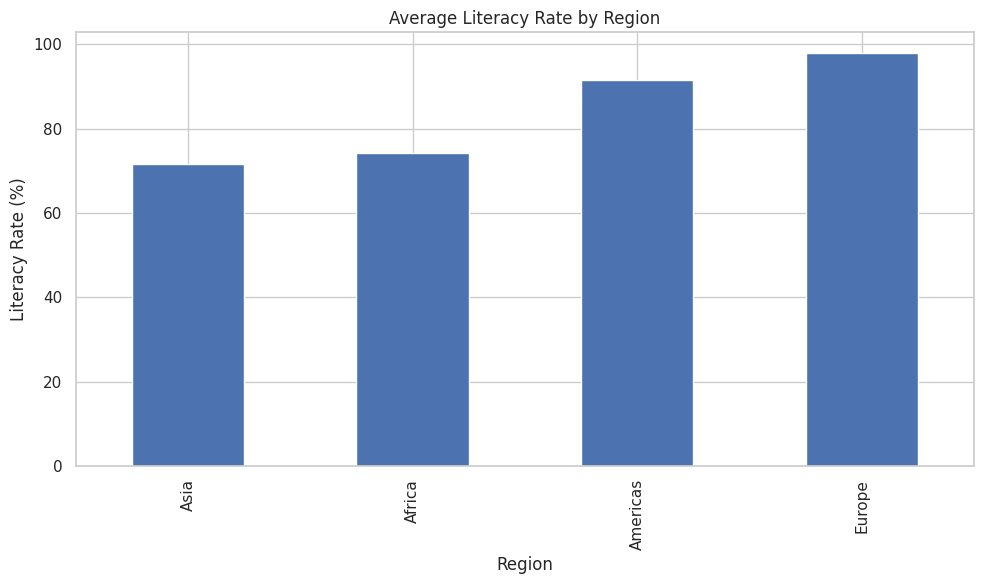

In [24]:
# Visualize literacy by region

plt.figure(figsize=(10,6))

region_literacy.sort_values().plot(kind="bar")

plt.title("Average Literacy Rate by Region")
plt.xlabel("Region")
plt.ylabel("Literacy Rate (%)")

plt.tight_layout()
plt.show()

### Interpretation of Results

This visualization shows clear differences in average literacy rates across regions. Europe has the highest average literacy rate at approximately 98%, while the Americas also show relatively high literacy at about 92%.

In contrast, Asia (about 72%) and Africa (about 74%) have lower average literacy rates, although the difference between these two regions is relatively small compared to the gap with Europe and the Americas.

These patterns suggest significant global inequality in education outcomes, likely influenced by differences in economic development, access to schooling, and long-term investment in education systems across regions.

## Question 4: Are there any long-term trends or patterns in literacy improvement?

In this section, I will analyze how literacy rates have changed over time within countries. Instead of looking at a single year, I will compare the earliest and latest available literacy rates for each country to measure long-term improvement.

In [29]:
# Question 4: Are there any long-term trends or patterns in literacy improvement?

# Sort dataset by year to ensure correct ordering
df_sorted = df.sort_values("Year")

# Get earliest literacy rate for each country
earliest = df_sorted.groupby("Country").first()

# Get latest literacy rate for each country
latest = df_sorted.groupby("Country").last()

# Create a new DataFrame to compare change over time
improvement = pd.DataFrame()

# Store country names
improvement["Country"] = earliest.index

# Calculate literacy improvement (latest - earliest)
improvement["Improvement"] = latest["Literacy Rate Among Adults"].values - earliest["Literacy Rate Among Adults"].values

# Sort by biggest improvement
improvement = improvement.sort_values("Improvement", ascending=False)

# Show top 10 most improved countries (changed to 11 to see Tunisia)
improvement.head(11)

,Country,Improvement
12,Bangladesh,50.00000
76,Iran,49.00000
120,Nepal,47.71250
115,Morocco,46.00000
25,Burundi,45.00000
184,United Arab Emirates,44.00000
69,Guinea-Bissau,43.93413
74,India,41.00000
146,Rwanda,41.00000
163,South Asia (WB),38.96951


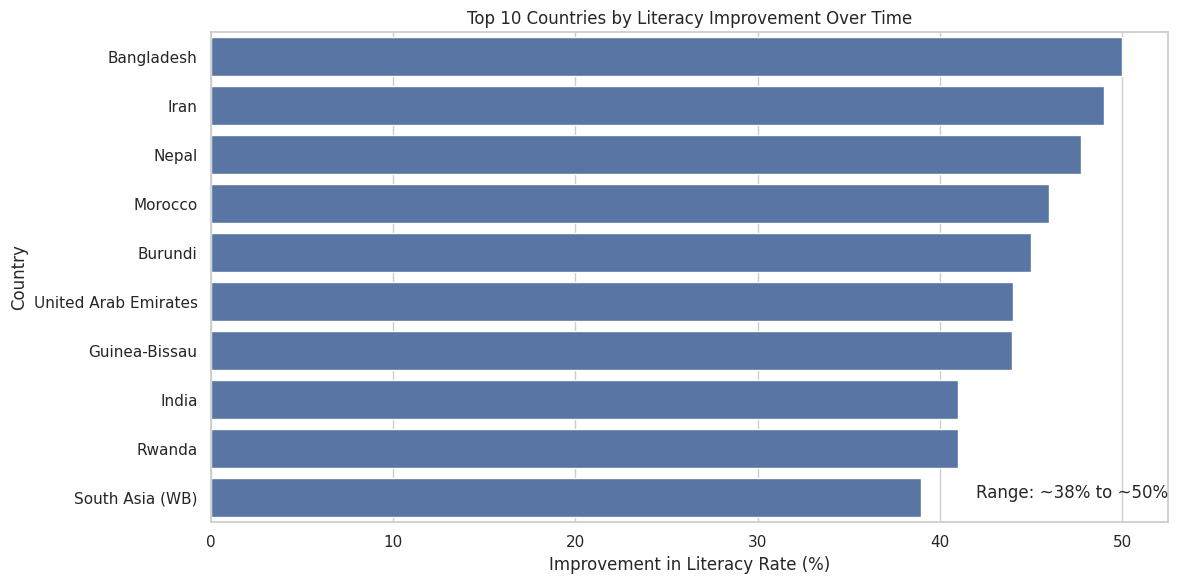

In [79]:
# Visualize top 10 most improved countries

plt.figure(figsize=(12,6))

# Take top 10 improvements
top_improvers = improvement.head(10)

# Create bar plot
sns.barplot(
    data=top_improvers,
    x="Improvement",
    y="Country"
)

# Add labels and title
plt.title("Top 10 Countries by Literacy Improvement Over Time")
plt.xlabel("Improvement in Literacy Rate (%)")
plt.ylabel("Country")

# Annotation
plt.annotate(
    "Range: ~38% to ~50%",
    xy=(40, 0),
    xytext=(42, 9),
)

plt.tight_layout()
plt.show()

### What is South Asia (WB) and Why is it With the Countries?

Some entries in the dataset represent regional aggregates rather than individual countries (e.g., "South Asia (WB)"). These are included in the dataset because organizations such as the World Bank compute regional averages for comparison purposes. However, they are excluded from country-level rankings to ensure a fair comparison between countries.

In [27]:
# Remove regional aggregates like "South Asia (WB)"
# "WB" is "World Bank," but not a country

improvement = improvement[~improvement["Country"].str.contains("South Asia")]

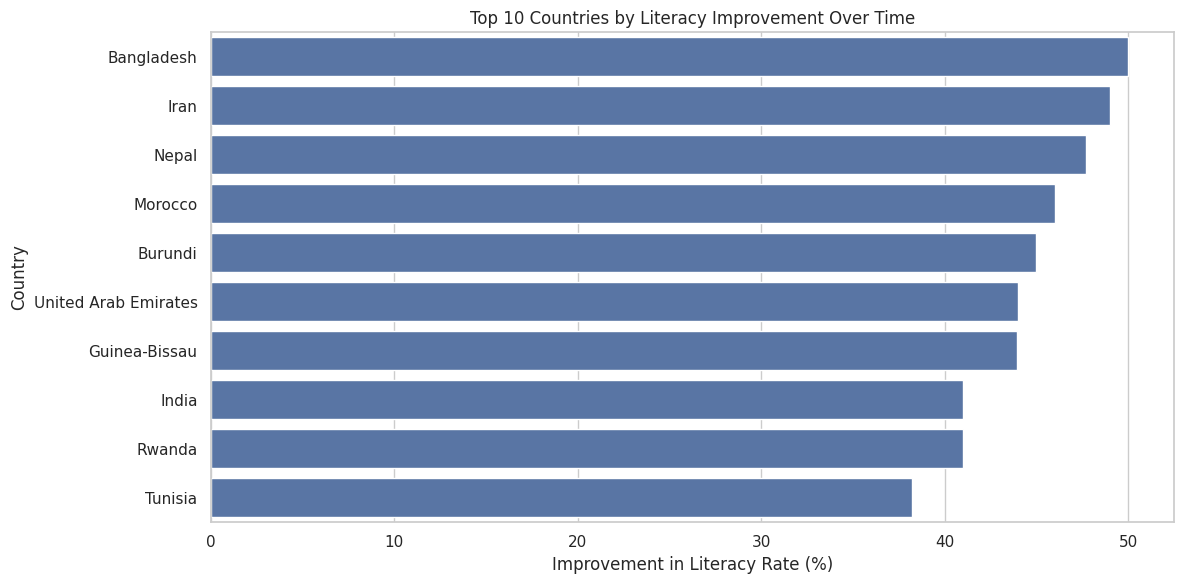

In [28]:
# Visualize top 10 most improved countries (without WBs)

plt.figure(figsize=(12,6))

# Take top 10 improvements
top_improvers = improvement.head(10)

# Create bar plot
sns.barplot(
    data=top_improvers,
    x="Improvement",
    y="Country"
)

# Add labels and title
plt.title("Top 10 Countries by Literacy Improvement Over Time")
plt.xlabel("Improvement in Literacy Rate (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Interpretation of Results

This visualization shows the countries with the largest improvements in literacy rates over time. The top improvers include Bangladesh (about 50%), Iran (about 49%), Nepal (about 48%), and Morocco (about 46%), followed closely by several countries in the 40–45% range such as Burundi, India, and Rwanda.

Overall, the results show substantial progress in literacy across a range of developing countries, suggesting improvements in access to education, literacy programs, and long-term development efforts.

However, the magnitude of improvement varies across countries, with some nations showing stronger gains than others. This highlights uneven global progress in education development.

It is also important to note that these improvements are calculated using each country’s earliest and latest available data, so the time periods of comparison differ across countries.

### NOTE: Limitation

This analysis compares the earliest and latest available literacy values for each country. Because countries report data in different years, the time span of comparison is not identical across all countries. Therefore, the improvements represent general long-term change rather than changes over a fixed time interval.

## Acknowledgements

I used AI tools to help debug and improve parts of this project.

- ChatGPT (OpenAI) was used to help troubleshoot coding errors and refine analysis steps.
- Google Gemini (built into Google Colab) was used to assist with debugging errors when I couldn't figure out why a code wasn't working.
- A SciPy document was used as a resource for my research to learn how to do my new technique, which was the line regression. I also incorporated the scipy library into my analysis to perform the regression calculations.
  - Link: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

All analysis, interpretation, and final decisions were my own.